# Phishing Email Cascading Pipeline with Local SLM (Week 15)

This notebook integrates the **Cascading/Routing Pipeline** using a **Local Small Language Model (SLM)**: **Qwen 2.5 7B Instruct** quantized in 4-bit. This architecture allows you to run evaluation on the **entire dataset** without encountering any API key requirements, daily token boundaries, or rate limit exceptions.

## How it works:
1. **Fast Local Track**: The notebook first passes the email to Hien's fine-tuned BERT classifier.
2. **Conditional Escalation**: If the confidence score is high (>= 85%), it makes the final decision immediately.
3. **Local SLM Fallback**: If the confidence score is borderline (< 85%), it escalates to the local Qwen 2.5 7B model using Chain-of-Thought (CoT) prompting.

In [1]:
# ====================================================
# Step 1: Install required dependencies
# ====================================================
!pip install transformers accelerate bitsandbytes pandas torch beautifulsoup4 scikit-learn

In [2]:
# ====================================================
# Step 2: Import libraries and select device
# ====================================================
import os
import re
import json
import time
import unicodedata
import pandas as pd
import torch
from bs4 import BeautifulSoup
from email import message_from_string
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM, BitsAndBytesConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Active device: {device}")

[*] Active device: cuda


In [3]:
# ====================================================
# Step 2.5: Download dataset from Google Drive (52MB)
# ====================================================
import os
import gdown

dataset_path = "/content/Phishing_Email.csv"

if not os.path.exists(dataset_path):
    print("[*] Downloading Phishing_Email.csv from Google Drive...")
    url = "https://drive.google.com/uc?id=1koq5-e8hgdzaMyFbZH6zgfc9ZLt9Ylq-"
    gdown.download(url, dataset_path, quiet=False)
    print("[+] Download complete!")
else:
    print(f"[+] Dataset already exists at {dataset_path}")

[+] Dataset already exists at /content/Phishing_Email.csv


In [4]:
# ====================================================
# Step 3: Define EmailParser Class
# ====================================================
class EmailParser:
    @staticmethod
    def clean_text(text):
        if not text:
            return ""
        # Strip HTML tags using BeautifulSoup
        text = BeautifulSoup(text, "html.parser").get_text()
        # Normalize Unicode NFKC form to prevent homoglyph masquerading attacks
        text = unicodedata.normalize("NFKC", text)
        # Strip zero-width spaces and control characters
        text = re.sub(r'[\u200b-\u200d\ufeff]', '', text)
        # Collapse multiple whitespaces
        text = re.sub(r'\s+', ' ', text)
        return text.strip()

    @staticmethod
    def parse_raw_email(raw_email_str):
        msg = message_from_string(raw_email_str)
        subject = msg.get('Subject', '')
        sender = msg.get('From', '')
        body = ""

        if msg.is_multipart():
            for part in msg.walk():
                content_type = part.get_content_type()
                if content_type == 'text/plain':
                    body += part.get_payload(decode=True).decode(errors='ignore')
        else:
            body = msg.get_payload(decode=True).decode(errors='ignore')

        clean_subj = EmailParser.clean_text(subject)
        clean_body = EmailParser.clean_text(body)

        # Extract URL strings using regex pattern matching
        urls = re.findall(r'https?://[^\s<>"]+|www\.[^\s<>"]+', body)

        return {
            "sender": sender,
            "subject": clean_subj,
            "body": clean_body,
            "urls": list(set(urls))
        }

In [5]:
# ====================================================
# Step 4: Define LocalPhishingPromptEngine Class (Local Qwen CoT)
# ====================================================
class LocalPhishingPromptEngine:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer

    def _extract_and_parse_json(self, raw_text):
        try:
            return json.loads(raw_text.strip())
        except json.JSONDecodeError:
            match = re.search(r'(\{.*\})', raw_text, re.DOTALL)
            if match:
                try:
                    return json.loads(match.group(1).strip())
                except json.JSONDecodeError:
                    pass
            return {
                "label": "error",
                "justification": "Failed to parse JSON response from LLM",
                "raw_response": raw_text
            }

    def run_chain_of_thought(self, email_data):
        prompt = f"""You are a SOC analyst inspecting a suspicious email.
Conduct a step-by-step threat analysis on the email details provided below:
1. Examine the sender domain for spoofing or look-alikes.
2. Evaluate the text tone (urgency, authority, emotional manipulation).
3. Analyze the calls-to-action, links, and attachments.
4. Output your analysis step-by-step inside the "reasoning_steps" field, followed by the final decision.

Email Subject: {email_data['subject']}
Email Sender: {email_data['sender']}
Email Body: {email_data['body']}

Output JSON format:
{{
  "reasoning_steps": [
    "Step 1 analysis...",
    "Step 2 analysis..."
  ],
  "label": "phishing" | "benign",
  "confidence_score": 0.0 to 1.0
}}
"""
        messages = [
            {"role": "system", "content": "You are a helpful assistant. You must output strictly in JSON format."},
            {"role": "user", "content": prompt}
        ]

        start_time = time.time()
        try:
            # Format chat template using Qwen structure
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )
            model_inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)

            with torch.no_grad():
                generated_ids = self.model.generate(
                    **model_inputs,
                    max_new_tokens=512,
                    temperature=0.1,
                    do_sample=False
                )
            # Extract generation slice
            generated_ids = [
                output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
            ]
            response_text = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

            result = self._extract_and_parse_json(response_text)
            return result.get("label", "error"), time.time() - start_time
        except Exception as e:
            return "error", time.time() - start_time

In [ ]:
# ====================================================
# Step 5: Load Hien's BERT Model directly from HF Hub
# ====================================================
# Define evaluation call wrapper for the BERT classifier returning confidence score

# Free up GPU memory before loading to avoid VRAM overflow (CUDA Out of Memory).
import gc
import torch
from pathlib import Path

for var in ['model_slm', 'model_bert']:
    if var in globals():
        del globals()[var]
gc.collect()
torch.cuda.empty_cache()

# model_repo = "harrynguyen5/phishing-bert-model"
model_repo = "kienleag15/phishing-bert"
print(f"[*] Downloading and loading BERT model from Hugging Face Hub: {model_repo}...")
tokenizer_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
model_bert = AutoModelForSequenceClassification.from_pretrained(model_repo)
model_bert = model_bert.to(device)  # Move model weights to GPU memory
model_bert.eval()
print("[+] BERT model successfully loaded!")

def predict_hien_bert(email_text):
    start_time = time.time()
    inputs = tokenizer_bert(
        email_text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model_bert(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[0]
        predicted_class_id = torch.argmax(probs).item()
        confidence = probs[predicted_class_id].item()

    label_map = {0: "phishing email", 1: "safe email"}
    return label_map[predicted_class_id], confidence, time.time() - start_time

[*] Downloading and loading BERT model from Hugging Face Hub: /content/drive/MyDrive/dataset/phishing-bert-v2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[+] BERT model successfully loaded!


In [8]:
# ====================================================
# Step 6: Load Local Qwen 2.5 7B Instruct Model in 4-bit Quantization
# ====================================================

print("[*] Downloading and loading Qwen 2.5 7B Instruct (4-bit)... This takes a few minutes.")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)
tokenizer_slm = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")
model_slm = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-7B-Instruct",
    quantization_config=bnb_config,
    device_map="auto"
)
prompt_engine = LocalPhishingPromptEngine(model_slm, tokenizer_slm)
print("[+] Qwen 2.5 7B Instruct local model successfully loaded!")

[*] Downloading and loading Qwen 2.5 7B Instruct (4-bit)... This takes a few minutes.


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[+] Qwen 2.5 7B Instruct local model successfully loaded!


In [9]:
# ====================================================
# Step 7: Define Cascading Pipeline Routing Logic
# ====================================================
def run_cascade_pipeline(email_data, threshold=0.65):
    # 1. Run local BERT first
    # NOTE (known limitation): BERT receives the cleaned body only, while the
    # Qwen escalation tier receives subject + sender + body. The two tiers see
    # different views of the same email, and BERT's training inputs additionally
    # carried a prompt prefix and structured headers. The next iteration should
    # use one canonical input format (subject + body) for training and both tiers.
    pred_bert, confidence, latency_bert = predict_hien_bert(email_data["body"])

    # 2. Check threshold
    if confidence >= threshold:
        # Return BERT's prediction directly ("phishing email" or "safe email")
        return pred_bert, latency_bert, False  # escalated = False

    # 3. Escalate to Qwen 2.5 local CoT
    print(f"[!] Borderline confidence ({confidence:.2f} < {threshold}). Escalating to Qwen 2.5 local...")
    pred_cot, latency_cot = prompt_engine.run_chain_of_thought(email_data)

    # Normalize Qwen's "phishing"/"benign" output to match BERT labels.
    # Parse failures are COUNTED rather than silently defaulted — failing open
    # is the wrong default for a security system.
    _lbl = str(pred_cot).lower().strip()
    if _lbl == "phishing":
        normalized_label = "phishing email"
    else:
        if _lbl not in ("benign", "safe", "safe email"):
            globals()["qwen_parse_failures"] = globals().get("qwen_parse_failures", 0) + 1
            print(f"[!] Unparseable Qwen label ({_lbl!r}) — counted as parse failure, defaulting to safe.")
        normalized_label = "safe email"

    total_latency = latency_bert + latency_cot
    return normalized_label, total_latency, True  # escalated = True

In [10]:
# ====================================================
# Step 8: Run evaluation pipeline on dataset (with Google Drive Checkpoint & Resume)
# ====================================================
# Set this flag to True if you want to evaluate on all 18,600+ emails!
RUN_ON_ENTIRE_DATASET = True
SAMPLE_SIZE = 500
USE_GOOGLE_DRIVE_CHECKPOINT = True  # Set to True to mount Drive and save checkpoints
CHECKPOINT_BATCH_SIZE = 100          # Save to Drive and clear RAM every N records

dataset_path = "Phishing_Email.csv"
checkpoint_path = "/content/test_predictions.csv" # Default local path

if USE_GOOGLE_DRIVE_CHECKPOINT:
    from google.colab import drive
    print("[*] Mounting Google Drive...")
    drive.mount('/content/drive')
    # Path to the synced Term Project dataaset folder
    drive_dir = '/content/drive/MyDrive/Term_Project_Phishing_Pipeline'
    os.makedirs(drive_dir, exist_ok=True)
    checkpoint_path = os.path.join(drive_dir, "test_predictions.csv")
    print(f"[+] Google Drive mounted. Checkpoints will be saved to: {checkpoint_path}")

if not os.path.exists(dataset_path):
    print(f"[-] Error: Phishing_Email.csv not found. Please run the download cell (Step 2.5) first.")
else:
    print(f"[+] Reading dataset from: {dataset_path}")
    df = pd.read_csv(dataset_path, on_bad_lines='skip')

    if RUN_ON_ENTIRE_DATASET:
        test_df = df
        print(f"[*] Configured to run on the ENTIRE dataset ({len(test_df)} records)...")
    else:
        test_df = df.sample(n=SAMPLE_SIZE, random_state=42)
        print(f"[*] Sampling {SAMPLE_SIZE} random records for evaluation...")

    # ----------------------------------------------------
    # Check for existing checkpoint to resume
    # ----------------------------------------------------
    start_idx = 0
    if os.path.exists(checkpoint_path):
        try:
            existing_df = pd.read_csv(checkpoint_path, encoding='utf-8-sig')
            start_idx = len(existing_df)
            print(f"[+] Found existing checkpoint with {start_idx} processed records.")
            if start_idx >= len(test_df):
                print("[+] All records have already been processed! No new evaluations needed.")
                test_df = test_df.iloc[0:0] # empty dataframe
            else:
                test_df = test_df.iloc[start_idx:]
                print(f"[+] Resuming evaluation from record {start_idx + 1}...")
        except Exception as e:
            print(f"[!] Warning: Failed to read checkpoint, starting from scratch. Error: {e}")

    results = []
    total_records = len(test_df)

    if total_records > 0:
        print(f"[*] Starting evaluation pipeline for {total_records} remaining records...")
        for idx, (index, row) in enumerate(test_df.iterrows()):
            raw_text = str(row["Email Text"])
            true_label = str(row["Email Type"])

            # A. Preprocess and parse raw email body
            parsed_email = EmailParser.parse_raw_email(raw_text)
            email_body = parsed_email["body"]

            # B. Run local BERT classifier
            pred_bert, confidence_bert, latency_bert = predict_hien_bert(email_body)

            # C. Run Cascading/Routing Pipeline
            pred_cascade, latency_cascade, escalated = run_cascade_pipeline(parsed_email)

            results.append({
                "email_text": email_body[:25000],  # Truncate to avoid Excel's 32,767 character cell limit
                "true_label": true_label.lower().strip(),
                "pred_hien_bert": pred_bert.lower().strip(),
                "bert_confidence": confidence_bert,  # Store confidence for threshold tuning\n
                "pred_cascade": pred_cascade.lower().strip(),
                "latency_hien_bert": latency_bert,
                "latency_cascade": latency_cascade,
                "cascade_escalated": escalated
            })

            # Save checkpoints periodically to prevent loss and free RAM
            current_num_processed = start_idx + idx + 1
            if (idx + 1) % CHECKPOINT_BATCH_SIZE == 0 or (idx + 1) == total_records:
                batch_df = pd.DataFrame(results)

                # Write to primary checkpoint path (Google Drive)
                drive_file_exists = os.path.exists(checkpoint_path)
                batch_df.to_csv(checkpoint_path, mode='a', index=False, header=not drive_file_exists, encoding='utf-8-sig')

                # Write a copy to local colab for redundancy
                local_file_exists = os.path.exists("test_predictions.csv")
                batch_df.to_csv("test_predictions.csv", mode='a', index=False, header=not local_file_exists, encoding='utf-8-sig')

                results = []  # Clear RAM list to prevent static memory exhaustion!
                print(f"[+] Saved checkpoint batch up to record {current_num_processed} to: {checkpoint_path}")

            if (idx + 1) % 10 == 0 or (RUN_ON_ENTIRE_DATASET and (idx + 1) % 100 == 0):
                print(f"[+] Evaluated {current_num_processed} records...")

        print(f"\n[+] SUCCESS: Evaluation complete! Final results are at: {checkpoint_path}")
    else:
        print("[+] No new evaluation needed. File is already complete.")


[*] Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[+] Google Drive mounted. Checkpoints will be saved to: /content/drive/MyDrive/Term_Project_Phishing_Pipeline/test_predictions.csv
[+] Reading dataset from: Phishing_Email.csv
[*] Configured to run on the ENTIRE dataset (18650 records)...
[*] Starting evaluation pipeline for 18650 remaining records...
[+] Evaluated 10 records...
[+] Evaluated 20 records...
[+] Evaluated 30 records...
[+] Evaluated 40 records...
[+] Evaluated 50 records...
[+] Evaluated 60 records...
[+] Evaluated 70 records...
[+] Evaluated 80 records...
[+] Evaluated 90 records...
[+] Saved checkpoint batch up to record 100 to: /content/drive/MyDrive/Term_Project_Phishing_Pipeline/test_predictions.csv
[+] Evaluated 100 records...
[+] Evaluated 110 records...
[+] Evaluated 120 records...
[+] Evaluated 130 records...
[+] Evaluated 140 records...
[+] Evaluated 150 r

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[+] Evaluated 240 records...
[!] Borderline confidence (0.63 < 0.65). Escalating to Qwen 2.5 local...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[+] Evaluated 250 records...
[+] Evaluated 260 records...
[+] Evaluated 270 records...
[+] Evaluated 280 records...
[+] Evaluated 290 records...
[+] Saved checkpoint batch up to record 300 to: /content/drive/MyDrive/Term_Project_Phishing_Pipeline/test_predictions.csv
[+] Evaluated 300 records...
[+] Evaluated 310 records...
[+] Evaluated 320 records...
[+] Evaluated 330 records...
[+] Evaluated 340 records...
[+] Evaluated 350 records...
[+] Evaluated 360 records...
[+] Evaluated 370 records...
[+] Evaluated 380 records...
[+] Evaluated 390 records...
[+] Saved checkpoint batch up to record 400 to: /content/drive/MyDrive/Term_Project_Phishing_Pipeline/test_predictions.csv
[+] Evaluated 400 records...
[+] Evaluated 410 records...
[+] Evaluated 420 records...
[+] Evaluated 430 records...
[+] Evaluated 440 records...
[+] Evaluated 450 records...
[!] Borderline confidence (0.58 < 0.65). Escalating to Qwen 2.5 local...
[+] Evaluated 460 records...
[+] Evaluated 470 records...
[+] Evaluated 

[+] Loading predictions from: /content/drive/MyDrive/Term_Project_Phishing_Pipeline/test_predictions.csv


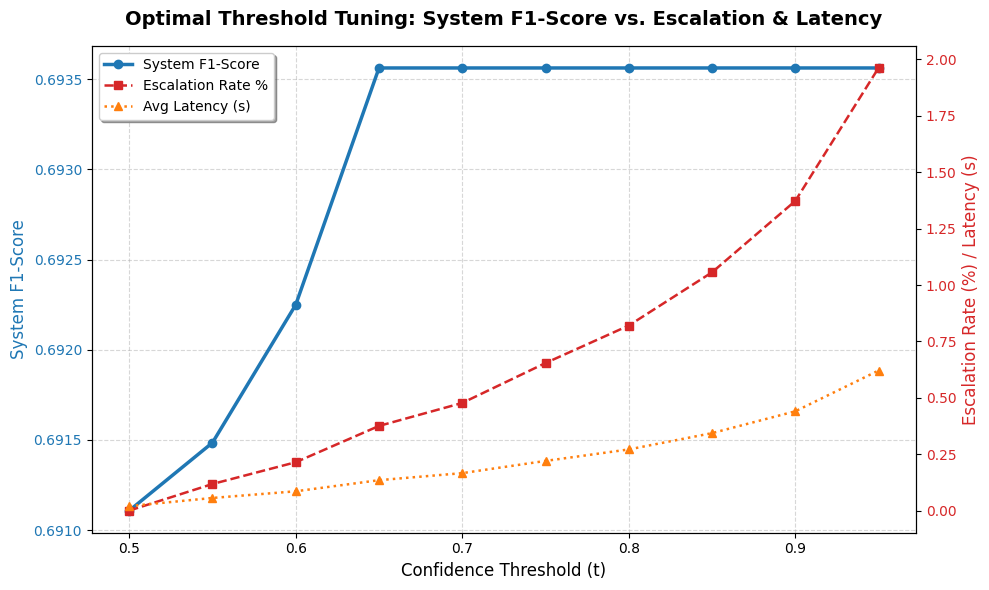


[+] RECOMMENDATION: Optimal threshold is likely near: 0.65
    - Predicted F1-Score: 0.6936
    - Escalation Rate: 0.4% of emails
    - Average Latency: 0.135 seconds per email


In [11]:
# ====================================================
# Step 9: Plot Threshold Trade-off Curve (F1-Score vs. Escalation Rate & Latency)
# ====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
import os

# Read the generated predictions file
if not os.path.exists(checkpoint_path):
    print(f"[-] Error: Could not find output predictions file at: {checkpoint_path}")
    print("[*] Please run Step 8 first to generate the evaluation dataset.")
else:
    print(f"[+] Loading predictions from: {checkpoint_path}")
    df = pd.read_csv(checkpoint_path, encoding='utf-8-sig')

    if "bert_confidence" not in df.columns:
        print("[-] Error: 'bert_confidence' column not found in predictions CSV.")
        print("[*] Please make sure you are running the updated Step 8 code.")
    else:
        # Map labels to binary values for metric calculation (1: phishing, 0: safe)
        y_true = df["true_label"].apply(lambda x: 1 if "phishing" in str(x).lower() else 0).values

        # Calculate metrics for different thresholds
        thresholds = np.arange(0.5, 1.0, 0.05)
        f1_scores = []
        escalation_rates = []
        avg_latencies = []

        # Estimate average latencies
        latency_bert_avg = df["latency_hien_bert"].mean()
        # Find average LLM overhead latency
        escalated_cases = df[df["cascade_escalated"] == True]
        if len(escalated_cases) > 0:
            latency_llm_avg = escalated_cases["latency_cascade"].mean() - escalated_cases["latency_hien_bert"].mean()
        else:
            latency_llm_avg = 2.0  # Fallback estimate (2 seconds)

        for t in thresholds:
            pred_final = []
            escalated_count = 0
            total_latency = 0

            for idx, row in df.iterrows():
                conf = row["bert_confidence"]
                if conf >= t:
                    pred_final.append(1 if "phishing" in str(row["pred_hien_bert"]).lower() else 0)
                    total_latency += row["latency_hien_bert"]
                else:
                    pred_final.append(1 if "phishing" in str(row["pred_cascade"]).lower() else 0)
                    escalated_count += 1
                    total_latency += (row["latency_hien_bert"] + latency_llm_avg)

            f1 = f1_score(y_true, pred_final)
            esc_rate = (escalated_count / len(df)) * 100
            avg_lat = total_latency / len(df)

            f1_scores.append(f1)
            escalation_rates.append(esc_rate)
            avg_latencies.append(avg_lat)

        # Plot the double Y-axis Trade-off curve
        fig, ax1 = plt.subplots(figsize=(10, 6))

        color = 'tab:blue'
        ax1.set_xlabel('Confidence Threshold (t)', fontsize=12)
        ax1.set_ylabel('System F1-Score', color=color, fontsize=12)
        ax1.plot(thresholds, f1_scores, marker='o', color=color, linewidth=2.5, label='System F1-Score')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.grid(True, linestyle='--', alpha=0.5)

        ax2 = ax1.twinx()
        color = 'tab:red'
        ax2.set_ylabel('Escalation Rate (%) / Latency (s)', color=color, fontsize=12)
        ax2.plot(thresholds, escalation_rates, marker='s', linestyle='--', color='tab:red', linewidth=1.8, label='Escalation Rate %')
        ax2.plot(thresholds, avg_latencies, marker='^', linestyle=':', color='tab:orange', linewidth=1.8, label='Avg Latency (s)')
        ax2.tick_params(axis='y', labelcolor=color)

        # Add legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, shadow=True)

        plt.title('Optimal Threshold Tuning: System F1-Score vs. Escalation & Latency', fontsize=14, fontweight='bold', pad=15)
        fig.tight_layout()
        plt.show()

        # Print recommendation based on elbow point
        best_idx = np.argmax(np.array(f1_scores) - (np.array(escalation_rates) / 200.0))
        print(f"\n[+] RECOMMENDATION: Optimal threshold is likely near: {thresholds[best_idx]:.2f}")
        print(f"    - Predicted F1-Score: {f1_scores[best_idx]:.4f}")
        print(f"    - Escalation Rate: {escalation_rates[best_idx]:.1f}% of emails")
        print(f"    - Average Latency: {avg_latencies[best_idx]:.3f} seconds per email")
